# Mạng Nơ-ron Hồi quy (RNN)

## 1. Giới thiệu về RNN

RNN là một loại mạng nơ-ron được thiết kế để xử lý *dữ liệu tuần tự* (sequential data) — như chuỗi thời gian, văn bản, hoặc âm thanh. Điểm đặc biệt của RNN là khả năng "ghi nhớ" thông tin từ các bước trước đó nhờ một vòng lặp ngầm trong kiến trúc.

### Tại sao cần RNN?

Hãy thử nghĩ: nếu mình muốn dự đoán từ tiếp theo trong câu "Tôi thích ăn ___", thì rõ ràng câu trả lời phụ thuộc vào các từ trước đó. Một mạng feedforward (ANN) thông thường nhìn từng input độc lập, nó không có cơ chế nào để "nhớ" rằng vừa nãy đã thấy chữ "thích". RNN giải quyết bằng cách mang theo một **trạng thái ẩn** $h_t$ qua các bước thời gian, đóng vai trò như bộ nhớ ngắn hạn của mạng.

### Một số ứng dụng

- Dự đoán chuỗi thời gian: giá cổ phiếu, nhiệt độ, lượng khách.
- Xử lý ngôn ngữ tự nhiên: dịch máy, sinh văn bản, gán nhãn từ loại.
- Nhận diện giọng nói, tổng hợp tiếng nói.

## 2. Cấu trúc của RNN

Tại mỗi bước thời gian $t$, RNN có ba đại lượng:

- **Đầu vào** $x_t$
- **Trạng thái ẩn** $h_t$ — bộ nhớ tích luỹ
- **Đầu ra** $y_t$

Trạng thái ẩn $h_t$ vừa được sinh ra từ $h_{t-1}$ và $x_t$, vừa là "đầu vào" cho bước kế tiếp $h_{t+1}$. Cùng một bộ trọng số được dùng cho mọi bước thời gian — đây gọi là **chia sẻ trọng số** (weight sharing), điểm tinh tế giúp RNN xử lý chuỗi có độ dài bất kỳ với số tham số cố định.

![Sơ đồ kiến trúc RNN cuộn theo thời gian](attachment:rnn_arch.png)


## 3. Công thức toán học của RNN

Tại mỗi thời điểm $t$, mô hình nhận đầu vào $x_t$, kết hợp với trạng thái ẩn từ bước trước $h_{t-1}$, rồi tạo ra trạng thái ẩn mới $h_t$. Từ trạng thái ẩn này, mô hình tính đầu ra $y_t$.

### 3.1. Công thức tính trạng thái ẩn

$$
h_t = f(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$

Trong đó:
- $x_t$: vector đầu vào tại thời điểm $t$
- $h_{t-1}$: trạng thái ẩn của bước liền trước
- $W_{xh}$: ma trận trọng số nối đầu vào với trạng thái ẩn
- $W_{hh}$: ma trận trọng số hồi quy (recurrent), nối $h_{t-1}$ với $h_t$
- $b_h$: bias của tầng ẩn
- $f$: hàm kích hoạt phi tuyến, thường là $\tanh$

Có thể đọc công thức theo nghĩa: trạng thái ẩn mới = một sự pha trộn giữa thông tin hiện tại ($x_t$) và thông tin quá khứ ($h_{t-1}$), rồi nén qua phi tuyến.

#### Ví dụ minh hoạ bằng số

Giả sử:
$$x_t = [0.5,\ 0.1]^T, \quad h_{t-1} = [0.2,\ 0.3]^T$$
$$W_{xh} = \begin{bmatrix}0.1 & 0.2\\ 0.3 & 0.4\end{bmatrix}, \quad W_{hh} = \begin{bmatrix}0.5 & 0.6\\ 0.7 & 0.8\end{bmatrix}, \quad b_h = [0.1,\ 0.2]^T$$

**Bước 1.** Phần đóng góp của đầu vào:
$$W_{xh}x_t = \begin{bmatrix}0.1\cdot 0.5 + 0.2\cdot 0.1\\ 0.3\cdot 0.5 + 0.4\cdot 0.1\end{bmatrix} = \begin{bmatrix}0.07\\ 0.19\end{bmatrix}$$

**Bước 2.** Phần đóng góp của quá khứ:
$$W_{hh}h_{t-1} = \begin{bmatrix}0.5\cdot 0.2 + 0.6\cdot 0.3\\ 0.7\cdot 0.2 + 0.8\cdot 0.3\end{bmatrix} = \begin{bmatrix}0.28\\ 0.38\end{bmatrix}$$

**Bước 3.** Cộng cả hai và bias:
$$\begin{bmatrix}0.07\\ 0.19\end{bmatrix} + \begin{bmatrix}0.28\\ 0.38\end{bmatrix} + \begin{bmatrix}0.1\\ 0.2\end{bmatrix} = \begin{bmatrix}0.45\\ 0.77\end{bmatrix}$$

**Bước 4.** Áp dụng $\tanh$:
$$h_t = \tanh([0.45,\ 0.77]^T) \approx [0.422,\ 0.647]^T$$

### 3.2. Công thức tính đầu ra

$$
y_t = g(W_{hy}h_t + b_y)
$$

Hàm $g$ tuỳ bài toán:
- **Sigmoid** cho phân loại nhị phân.
- **Softmax** cho phân loại nhiều lớp.
- **Không hàm kích hoạt** (identity) cho hồi quy.

#### Tiếp nối ví dụ

Với $W_{hy} = [0.9,\ 0.8]$ và $b_y = 0.05$:
$$W_{hy}h_t + b_y = 0.9\cdot 0.422 + 0.8\cdot 0.647 + 0.05 \approx 0.947$$
$$y_t = \sigma(0.947) = \frac{1}{1 + e^{-0.947}} \approx 0.720$$

## 4. Huấn luyện RNN — Backpropagation Through Time (BPTT)

RNN được huấn luyện bằng thuật toán **lan truyền ngược qua thời gian**. Ý tưởng: "trải" mạng theo từng bước thời gian thành một mạng phẳng dài $T$ tầng, rồi chạy backprop bình thường — chỉ khác là tất cả các "tầng" này dùng *chung một bộ trọng số*.

Tổng loss trên cả chuỗi:
$$
L = \sum_{t=1}^{T} L_t
$$

### Vì sao gradient biến mất? Một chứng minh ngắn

Khi tính $\partial L_t / \partial W_{hh}$, đạo hàm phải đi qua chuỗi các trạng thái ẩn từ $h_t$ về $h_1$:

$$
\frac{\partial L_t}{\partial W_{hh}} = \sum_{k=1}^{t} \frac{\partial L_t}{\partial h_t}\Big(\prod_{j=k+1}^{t} \frac{\partial h_j}{\partial h_{j-1}}\Big)\frac{\partial h_k}{\partial W_{hh}}
$$

Cái tích $\prod \partial h_j/\partial h_{j-1}$ chính là điểm chết người. Mỗi nhân tử có dạng $\text{diag}(f'(\cdot)) \cdot W_{hh}$. Với $\tanh$, $f'$ luôn $\le 1$. Nếu giá trị riêng (eigenvalue) lớn nhất của $W_{hh}$ < 1, tích này **co lại theo cấp số nhân** khi $t-k$ lớn → gradient từ các bước xa gần như bằng 0. Đây là **vanishing gradient**.

Ngược lại, nếu eigenvalue > 1 thì tích bùng nổ → **exploding gradient** (xử lý dễ hơn nhiều: dùng `torch.nn.utils.clip_grad_norm_`).

Hệ quả thực tế: RNN cơ bản không học được phụ thuộc xa quá ~10-20 bước. Đó là động lực cho LSTM/GRU (bài sau).

![Lan truyền ngược qua thời gian (BPTT) — gradient chảy từ bước cuối về bước đầu, đi qua mọi $h_t$](attachment:vanish.png)


![Đường gradient magnitude teo dần theo bước thời gian — biểu hiện kinh điển của vanishing gradient](attachment:vanish2.png)


## 5. Ví dụ: dự đoán từ tiếp theo

Cho từ điển 3 từ: `["Tôi", "thích", "học"]`, biểu diễn one-hot là `[1,0,0]`, `[0,1,0]`, `[0,0,1]`.

Đưa lần lượt "Tôi" rồi "thích" vào RNN, ở bước thứ 2 mạng sinh ra một vector xác suất sau softmax:
$$y_2 = [0.1,\ 0.2,\ 0.7]$$

Vị trí lớn nhất là chỉ số 2 → từ "học". Mạng đoán câu tiếp theo là **"học"**. Điểm hay: dự đoán không chỉ dựa vào "thích" hiện tại, mà còn nhờ trạng thái ẩn đã "nhớ" được "Tôi" trước đó.

## 6. So sánh RNN với Feedforward NN

| **RNN** | **Feedforward NN** |
|---|---|
| Xử lý dữ liệu tuần tự, chiều dài bất kỳ | Đầu vào kích thước cố định, độc lập từng mẫu |
| Có trạng thái ẩn $h_t$ — bộ nhớ ngắn hạn | Không có bộ nhớ |
| Trọng số chia sẻ qua thời gian | Mỗi tầng có bộ trọng số riêng |
| Dễ vanishing gradient với chuỗi dài | Không có vấn đề này (nhưng có vấn đề khác như overfitting) |

# BÀI THỰC HÀNH: DỰ BÁO SÓNG SIN VỚI RNN

Ta sẽ dùng RNN để học dạng sóng sin có nhiễu, rồi dự đoán giá trị tiếp theo. Bài này có hai cách đánh giá khác nhau — và đây là chỗ dễ nhầm:

1. **One-step-ahead** (đánh giá chuẩn): mỗi bước dự đoán một giá trị, *dùng dữ liệu thật* làm input. Đây là metric đáng tin cậy.
2. **Rollout / Auto-regressive** (dự báo dài hạn): chỉ cho input ban đầu, sau đó *dùng output của chính mình* làm input cho bước tiếp theo. Sai số tích luỹ rất nhanh — model sẽ trôi (drift) theo hàm sin tưởng tượng của nó.

Cả hai đều có ý nghĩa, nhưng phải báo cáo riêng từng loại.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## Bước 1. Chuẩn bị dữ liệu

Sinh 200 điểm sóng sin có nhiễu, chuẩn hoá về [0, 1], rồi cắt thành các "cửa sổ trượt" độ dài 10. Mỗi mẫu huấn luyện sẽ có dạng: nhìn 10 giá trị quá khứ, đoán giá trị thứ 11.

X shape: torch.Size([190, 10, 1])  y shape: torch.Size([190, 1])
Train: 152, Test: 38


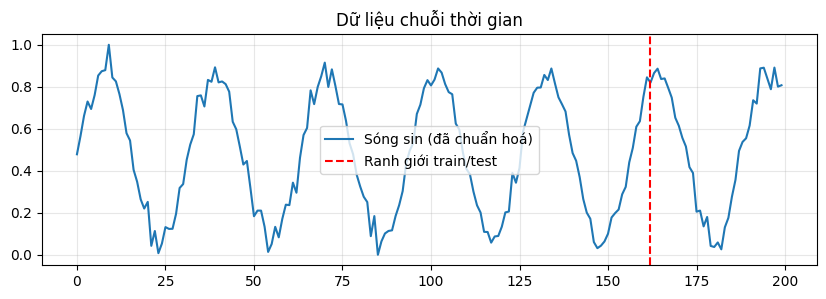

In [3]:
time_steps = 200
x = np.linspace(0, 40, time_steps)
data = np.sin(x) + 0.1 * np.random.randn(time_steps)

# Chuẩn hoá min-max về [0, 1] để output sigmoid hoặc tanh dễ học hơn.
data_min, data_max = data.min(), data.max()
data = (data - data_min) / (data_max - data_min)
data = torch.FloatTensor(data).unsqueeze(1)   # shape (200, 1)

def create_sequences(series, seq_length):
    X, y = [], []
    for i in range(len(series) - seq_length):
        X.append(series[i : i + seq_length])
        y.append(series[i + seq_length])
    return torch.stack(X), torch.stack(y)

seq_length = 10
X, y = create_sequences(data, seq_length)
print('X shape:', X.shape, ' y shape:', y.shape)   # (190, 10, 1) và (190, 1)

# Chia 80/20.
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

# Vẽ chuỗi gốc để có cảm giác về dữ liệu.
plt.figure(figsize=(10, 3))
plt.plot(data.numpy(), label='Sóng sin (đã chuẩn hoá)')
plt.axvline(train_size + seq_length, color='red', linestyle='--', label='Ranh giới train/test')
plt.legend(); plt.grid(alpha=0.3); plt.title('Dữ liệu chuỗi thời gian')
plt.show()

## Bước 2. Định nghĩa mô hình RNN

Một lớp `nn.RNN` đơn giản với `hidden_size = 20`, theo sau là một lớp Linear để biến trạng thái ẩn cuối cùng thành một số (giá trị dự đoán).

`batch_first=True` nghĩa là input có shape `(batch, seq_len, input_size)` — dễ đọc hơn cho người mới.

In [4]:
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # PyTorch tự khởi tạo h0 = 0 nếu mình không truyền vào.
        out, _ = self.rnn(x)             # out shape: (batch, seq_len, hidden_size)
        out = self.fc(out[:, -1, :])     # chỉ lấy bước cuối cùng → (batch, output_size)
        return out

model = RNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
print(model)

RNN(
  (rnn): RNN(1, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)


## Bước 3. Vòng lặp huấn luyện — phải duyệt qua tất cả batch

Lưu ý quan trọng: ở mỗi epoch ta phải duyệt qua **toàn bộ** tập train, chia thành nhiều batch. Cách dễ nhất là dùng `DataLoader`. Nhiều bạn lần đầu chỉ lấy ngẫu nhiên 1 batch mỗi epoch, dẫn đến model train cực kỳ thiếu hiệu quả (chỉ thấy được 16/152 mẫu mỗi epoch).

In [5]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)

num_epochs = 100
loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    avg_loss = epoch_loss / n_samples
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] loss = {avg_loss:.5f}')

Epoch [ 10/100] loss = 0.00233
Epoch [ 20/100] loss = 0.00320
Epoch [ 30/100] loss = 0.00219
Epoch [ 40/100] loss = 0.00241
Epoch [ 50/100] loss = 0.00261
Epoch [ 60/100] loss = 0.00235
Epoch [ 70/100] loss = 0.00268
Epoch [ 80/100] loss = 0.00322
Epoch [ 90/100] loss = 0.00210
Epoch [100/100] loss = 0.00221


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='red')
plt.xlabel('Epoch'); plt.ylabel('MSE loss'); plt.title('Đường cong loss')
plt.grid(alpha=0.3); plt.yscale('log')
plt.show()

## Bước 4. Đánh giá one-step-ahead (đáng tin cậy)

Mỗi mẫu test có 10 giá trị quá khứ thật → dự đoán 1 giá trị tiếp theo. Ta dùng `MSE` và `MAE` làm metric.

In [6]:
model.eval()
with torch.no_grad():
    pred_one_step = model(X_test).squeeze().numpy()
    truth        = y_test.squeeze().numpy()

mse = np.mean((pred_one_step - truth) ** 2)
mae = np.mean(np.abs(pred_one_step - truth))
print(f'One-step MSE = {mse:.5f},  MAE = {mae:.5f}')

# Baseline ngây thơ: "giá trị tiếp theo bằng giá trị cuối cùng đã thấy".
naive_pred = X_test[:, -1, 0].numpy()
mse_naive = np.mean((naive_pred - truth) ** 2)
print(f'Baseline (naive) MSE = {mse_naive:.5f}  ← RNN phải đánh bại con số này mới gọi là học được gì.')

One-step MSE = 0.00260,  MAE = 0.04201
Baseline (naive) MSE = 0.00577  ← RNN phải đánh bại con số này mới gọi là học được gì.


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(truth, 'o-', label='Thực tế')
plt.plot(pred_one_step, 's--', label='Dự đoán (one-step)')
plt.title('Đánh giá one-step-ahead trên tập test')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Bước 5. Dự báo dài hạn (rollout) — và lý do nó trôi

Bây giờ ta thử cho model một cửa sổ ban đầu, sau đó *liên tục đẩy output của model trở lại làm input*. Đây là kịch bản nếu ta muốn dự báo nhiều bước về tương lai mà không có dữ liệu thật.

Sai số mỗi bước rất nhỏ, nhưng tích luỹ qua hàng chục bước — model sẽ dần dần "lệch tông" so với sóng thật. Đây là minh hoạ kinh điển của vấn đề **error accumulation** trong dự báo chuỗi.

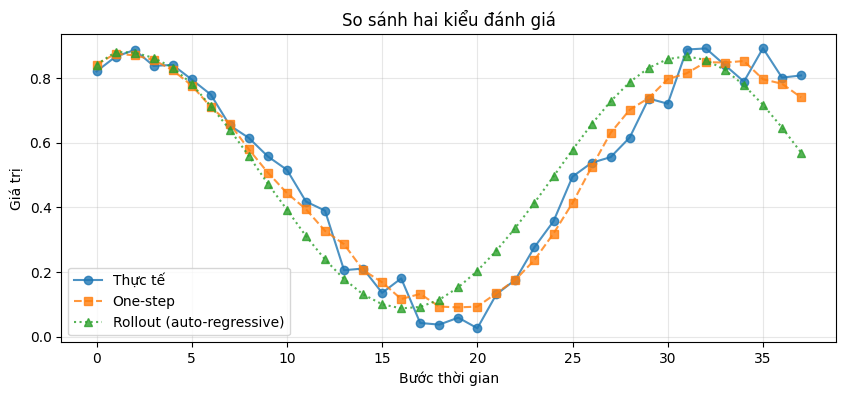

One-step MSE: 0.00260
Rollout  MSE: 0.01136  ← lớn hơn nhiều, đúng như dự đoán.


In [7]:
model.eval()
rollout = []
with torch.no_grad():
    inputs = X_test[0].unsqueeze(0).clone()   # shape (1, 10, 1)
    for _ in range(len(X_test)):
        out = model(inputs)                   # (1, 1)
        rollout.append(out.item())
        # Đẩy out vào cuối, bỏ phần tử đầu — cửa sổ trượt 1 bước.
        next_step = out.unsqueeze(0)          # (1, 1, 1)
        inputs = torch.cat([inputs[:, 1:, :], next_step], dim=1)

rollout = np.array(rollout)

plt.figure(figsize=(10, 4))
plt.plot(truth,           'o-', label='Thực tế', alpha=0.8)
plt.plot(pred_one_step,   's--', label='One-step', alpha=0.8)
plt.plot(rollout,         '^:', label='Rollout (auto-regressive)', alpha=0.8)
plt.title('So sánh hai kiểu đánh giá')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f'One-step MSE: {mse:.5f}')
print(f'Rollout  MSE: {np.mean((rollout - truth)**2):.5f}  ← lớn hơn nhiều, đúng như dự đoán.')

## Tổng kết bài lab

- RNN học được pattern tuần hoàn của sóng sin tốt khi đánh giá one-step.
- Khi rollout dài, sai số tích luỹ → model trôi. Đây không phải lỗi code, mà là bản chất của dự báo auto-regressive.
- Phải so sánh với baseline naive (gán giá trị cuối) để đảm bảo model thật sự *học được gì*, chứ không chỉ đoán "y hệt giá trị vừa rồi".
- Vòng lặp train phải duyệt toàn bộ batch mỗi epoch — không lấy ngẫu nhiên 1 batch.

# BÀI TẬP VỀ NHÀ

## Bài tập 1: Dự báo chuỗi thời gian đa biến

### Mô tả bài toán
Trong buổi học trên lớp, ta đã làm bài dự báo chuỗi thời gian đơn biến (chỉ một sóng sin). Bây giờ em sẽ làm việc với **dữ liệu đa biến** — gồm nhiều đặc trưng đầu vào, dự đoán một biến mục tiêu.

### Mục tiêu
- Tự xử lý dữ liệu chuỗi thời gian đa biến.
- Mở rộng kiến trúc RNN để nhận `input_size > 1`.
- So sánh tác động của các siêu tham số tới hiệu năng.

### Dữ liệu (đã sinh sẵn ở cell tiếp theo)
- `feature_1`: dạng sin
- `feature_2`: dạng cos
- `feature_3`: xu hướng tăng có nhiễu
- `target`: tổ hợp tuyến tính của ba đặc trưng + nhiễu

### Yêu cầu

**Phần A — Tiền xử lý**
- Chuẩn hoá tất cả các cột về [0, 1] (lưu ý: chỉ fit scaler trên train, sau đó áp dụng cho val/test — tránh data leakage).
- Tạo cửa sổ trượt `seq_length = 20`.
- Chia 70% train / 15% val / 15% test theo thứ tự thời gian (KHÔNG shuffle vì là chuỗi thời gian).

**Phần B — Mô hình**
- `input_size = 3`, `hidden_size = 32`, `output_size = 1`.
- Loss `MSELoss`, optimizer Adam, 150 epoch.
- Lưu cả train_loss và val_loss qua từng epoch.

**Phần C — Đánh giá**
- Trên tập test: tính MSE, MAE.
- Vẽ biểu đồ so sánh giá trị thật và giá trị dự đoán.
- So sánh với baseline naive (giá trị tiếp theo = giá trị cuối cùng).

**Phần D — Phân tích nâng cao**
- Thử ít nhất 3 giá trị `seq_length` (10, 20, 30): MSE thay đổi thế nào?
- Thử `hidden_size ∈ {16, 32, 64}`: model nào underfit, model nào overfit?
- Thử thêm dropout: `nn.RNN(..., dropout=0.2, num_layers=2)`. Quan sát train_loss và val_loss.
- Viết một đoạn nhận xét khoảng 5-10 dòng về những gì em quan sát được.

### Gợi ý
- Cẩn thận khi reshape: `X` phải có shape `(num_samples, seq_length, input_size)`.
- Khi vẽ kết quả, nhớ "un-normalize" lại nếu muốn xem giá trị gốc.

**Hạn nộp:** 28/03/2026

   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


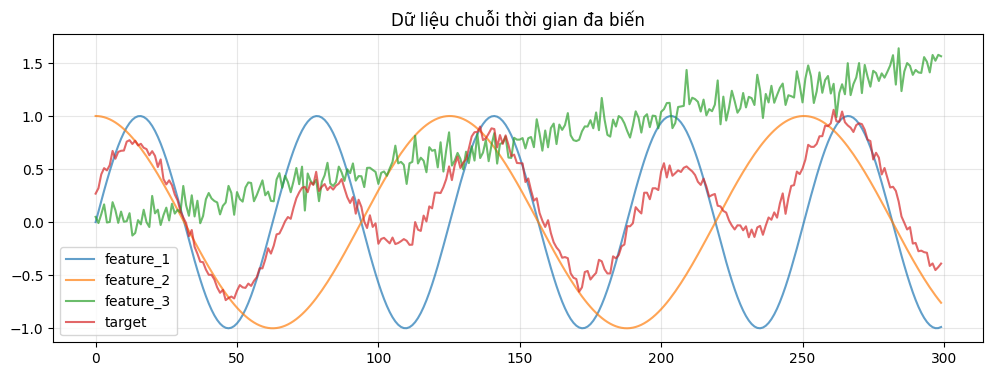

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)
feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target,
})
print(df.head())

plt.figure(figsize=(12, 4))
for col in df.columns:
    plt.plot(df[col], label=col, alpha=0.7)
plt.legend(); plt.grid(alpha=0.3)
plt.title('Dữ liệu chuỗi thời gian đa biến')
plt.show()

### Phần A — Tiền xử lý dữ liệu

In [9]:
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

# Khởi tạo scaler
scaler = MinMaxScaler()

# Chia dữ liệu theo thứ tự thời gian
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

total_samples = len(df)
train_end = int(total_samples * train_ratio)
val_end = int(total_samples * (train_ratio + val_ratio))

df_train = df.iloc[:train_end]
df_val = df.iloc[train_end:val_end]
df_test = df.iloc[val_end:]

# Chỉ fit scaler trên tập train, sau đó transform tất cả các tập
df_train_scaled = scaler.fit_transform(df_train)
df_val_scaled = scaler.transform(df_val)
df_test_scaled = scaler.transform(df_test)

df_train_scaled = pd.DataFrame(df_train_scaled, columns=df.columns)
df_val_scaled = pd.DataFrame(df_val_scaled, columns=df.columns)
df_test_scaled = pd.DataFrame(df_test_scaled, columns=df.columns)

print("Kích thước tập train_scaled:", df_train_scaled.shape)
print("Kích thước tập val_scaled:", df_val_scaled.shape)
print("Kích thước tập test_scaled:", df_test_scaled.shape)


Kích thước tập train_scaled: (210, 4)
Kích thước tập val_scaled: (45, 4)
Kích thước tập test_scaled: (45, 4)


In [10]:
def create_sequences_multivariate(data, seq_length):
    X, y = [], []
    # Lấy tất cả các cột trừ 'target' làm input features
    features = data.drop(columns=['target']).values
    # Lấy cột 'target' làm output
    targets = data['target'].values

    for i in range(len(data) - seq_length):
        X.append(features[i : i + seq_length])
        y.append(targets[i + seq_length])
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y)).unsqueeze(1)

seq_length = 20

X_train, y_train = create_sequences_multivariate(df_train_scaled, seq_length)
X_val, y_val = create_sequences_multivariate(df_val_scaled, seq_length)
X_test, y_test = create_sequences_multivariate(df_test_scaled, seq_length)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}, y_val shape: {y_val.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

# Tạo DataLoader
batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # Không shuffle cho chuỗi thời gian

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


X_train shape: torch.Size([190, 20, 3]), y_train shape: torch.Size([190, 1])
X_val shape: torch.Size([25, 20, 3]), y_val shape: torch.Size([25, 1])
X_test shape: torch.Size([25, 20, 3]), y_test shape: torch.Size([25, 1])


In [ ]:
# TODO: Phần A — tiền xử lý

### Phần B — Định nghĩa và huấn luyện mô hình

MultivariateRNN(
  (rnn): RNN(3, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Epoch [ 10/150] Train Loss: 0.01674, Val Loss: 0.00955
Epoch [ 20/150] Train Loss: 0.00459, Val Loss: 0.00521
Epoch [ 30/150] Train Loss: 0.00308, Val Loss: 0.00284
Epoch [ 40/150] Train Loss: 0.00222, Val Loss: 0.00196
Epoch [ 50/150] Train Loss: 0.00169, Val Loss: 0.00159
Epoch [ 60/150] Train Loss: 0.00140, Val Loss: 0.00140
Epoch [ 70/150] Train Loss: 0.00125, Val Loss: 0.00129
Epoch [ 80/150] Train Loss: 0.00118, Val Loss: 0.00122
Epoch [ 90/150] Train Loss: 0.00116, Val Loss: 0.00119
Epoch [100/150] Train Loss: 0.00115, Val Loss: 0.00118
Epoch [110/150] Train Loss: 0.00114, Val Loss: 0.00118
Epoch [120/150] Train Loss: 0.00113, Val Loss: 0.00118
Epoch [130/150] Train Loss: 0.00112, Val Loss: 0.00118
Epoch [140/150] Train Loss: 0.00112, Val Loss: 0.00118
Epoch [150/150] Train Loss: 0.00111, Val Loss: 0.00118


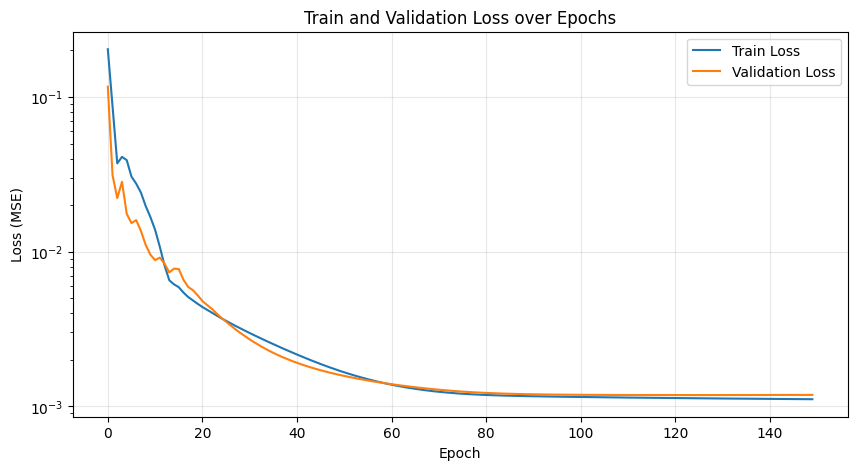

In [11]:
class MultivariateRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        # RNN nhận input_size là số lượng features (3 trong trường hợp này)
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

# Định nghĩa các siêu tham số
input_size = df.shape[1] - 1 # 3 features: feature_1, feature_2, feature_3
hidden_size = 32
output_size = 1 # Dự đoán 'target'
num_epochs = 150
learning_rate = 0.001

model_bt1 = MultivariateRNN(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_bt1.parameters(), lr=learning_rate)

print(model_bt1)

# Lịch sử loss
train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    # Huấn luyện
    model_bt1.train()
    epoch_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model_bt1(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * X_batch.size(0)
    avg_train_loss = epoch_train_loss / len(train_loader.dataset)
    train_loss_history.append(avg_train_loss)

    # Đánh giá trên tập validation
    model_bt1.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for X_batch_val, y_batch_val in val_loader:
            output_val = model_bt1(X_batch_val)
            val_loss = criterion(output_val, y_batch_val)
            epoch_val_loss += val_loss.item() * X_batch_val.size(0)
    avg_val_loss = epoch_val_loss / len(val_loader.dataset)
    val_loss_history.append(avg_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}')

# Vẽ biểu đồ loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Train and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()


In [ ]:
# TODO: Phần B — định nghĩa và train mô hình

### Phần C — Đánh giá trên tập test

MSE trên tập test (un-normalized): 0.00224
MAE trên tập test (un-normalized): 0.03888
Naive Baseline MSE (un-normalized): 0.00693
Naive Baseline MAE (un-normalized): 0.06607


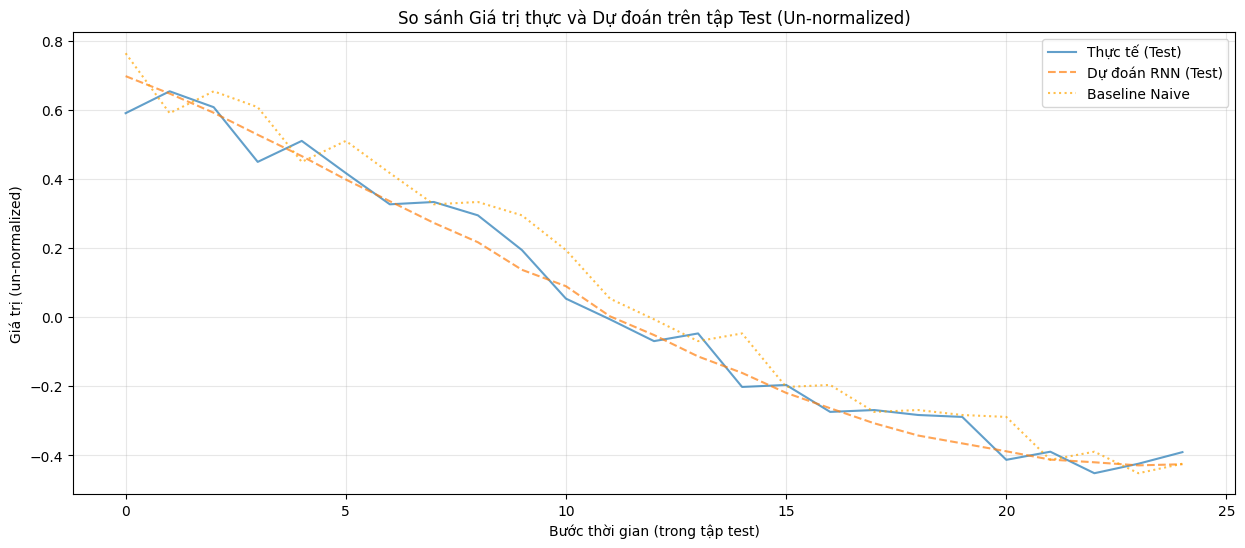

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

model_bt1.eval()
with torch.no_grad():
    test_predictions = model_bt1(X_test).squeeze().numpy()
    test_truth = y_test.squeeze().numpy()

# Để un-normalize target, ta cần tạo một scaler chỉ cho cột target
# Lấy scaler đã fit từ cột 'target' của df_train
target_scaler = MinMaxScaler()
# Tạo một DataFrame giả chỉ chứa cột 'target' để fit scaler
df_target_only = df[['target']]
target_scaler.fit(df_target_only.iloc[:train_end])

# Un-normalize dự đoán và giá trị thực
# predictions và truth có shape (N,) cần reshape (N,1) để inverse_transform
original_predictions = target_scaler.inverse_transform(test_predictions.reshape(-1, 1)).flatten()
original_truth = target_scaler.inverse_transform(test_truth.reshape(-1, 1)).flatten()

mse_test = mean_squared_error(original_truth, original_predictions)
mae_test = mean_absolute_error(original_truth, original_predictions)

print(f'MSE trên tập test (un-normalized): {mse_test:.5f}')
print(f'MAE trên tập test (un-normalized): {mae_test:.5f}')

# Baseline naive: giá trị tiếp theo = giá trị cuối cùng của cửa sổ
# Lấy giá trị cuối cùng của feature_3 trong X_test (là giá trị cuối cùng của cửa sổ input)
# Nhưng baseline đúng hơn là giá trị target cuối cùng của cửa sổ, không phải feature cuối cùng
# Để có baseline naive chính xác, cần lấy giá trị y_(t-1) thay vì x_t
# Ở đây, y_test là target của t+seq_length. Nếu baseline là y_(t+seq_length-1), thì ta phải lấy từ df_test_scaled

# Để làm đúng baseline naive, ta cần truy cập vào target của bước trước đó trong tập test.
# Đây là một chút phức tạp do cách tạo cửa sổ.
# Một cách đơn giản là lấy giá trị cuối cùng của target trong cửa sổ X_test làm dự đoán.
# Tuy nhiên, X_test chỉ chứa features, không chứa target.
# Giả sử baseline là giá trị cuối cùng của cột 'target' trong `seq_length` bước đầu vào của cửa sổ.
# Tức là, target[i+seq_length-1]

# Lấy target_scaled từ df_test_scaled
target_data_scaled = df_test_scaled['target'].values

# Tạo baseline naive cho tập test
# Đối với mỗi mẫu (X, y), y là target tại t+seq_length
# Naive prediction sẽ là target tại t+seq_length-1
# Tức là, y của mẫu trước đó, hoặc phần tử cuối cùng của target trong cửa sổ input (nếu có)

# Cách tạo naive_prediction đơn giản: dự đoán giá trị tiếp theo là giá trị cuối cùng của cửa sổ input target
# Do cách tạo create_sequences, y[i] là series[i+seq_length]
# Naive baseline sẽ là series[i+seq_length-1]

# Cần tạo lại naive_predictions từ df_test_scaled
naive_predictions_scaled = target_data_scaled[seq_length-1 : -1] # Lấy từ index seq_length-1 đến cuối (trừ phần tử cuối)
# naive_predictions_scaled sẽ ngắn hơn test_truth 1 phần tử nếu target_data_scaled là df_test_scaled['target']
# Cần điều chỉnh để khớp kích thước

# Lấy giá trị target trước đó từ `df_test` (un-normalized) để tính naive baseline
# Đây là giá trị `df['target']` tại `val_end + seq_length - 1` đến `val_end + len(df_test) - 2`

# Trích xuất phần target của dữ liệu test gốc
original_test_targets = df_test['target'].values

# Tạo naive predictions bằng cách dịch chuyển target gốc đi 1 bước
# Nếu `y_test[i]` là target của `t`, thì naive_pred[i] là target của `t-1`
# Do đó, naive_predictions sẽ là `original_test_targets` với một offset.

# Naive prediction: y_hat[t] = y[t-1] (giá trị trước đó)
# y_test bắt đầu từ chỉ số `seq_length` của `df_test_scaled['target']`
# Các giá trị target thực tế trên tập test bắt đầu từ `df_test.iloc[seq_length]['target']`
# Naive prediction cho `df_test.iloc[seq_length]['target']` sẽ là `df_test.iloc[seq_length-1]['target']`

# Vì `y_test` có kích thước `len(df_test) - seq_length`
# `original_truth` là `df_test['target'].values[seq_length:]` (un-normalized)

# Baseline naive sẽ là `df_test['target'].values[seq_length-1:-1]` (un-normalized)
naive_baseline_original = original_test_targets[seq_length-1:-1]

# Kiểm tra kích thước
# print(f'original_truth shape: {original_truth.shape}')
# print(f'naive_baseline_original shape: {naive_baseline_original.shape}')

# Cắt original_truth và original_predictions để khớp với naive_baseline_original
# Removed: original_truth_baseline_comp = original_truth[1:]
# Removed: original_predictions_baseline_comp = original_predictions[1:]

mse_naive = mean_squared_error(original_truth, naive_baseline_original)
mae_naive = mean_absolute_error(original_truth, naive_baseline_original)

print(f'Naive Baseline MSE (un-normalized): {mse_naive:.5f}')
print(f'Naive Baseline MAE (un-normalized): {mae_naive:.5f}')

# Vẽ biểu đồ so sánh
plt.figure(figsize=(15, 6))
plt.plot(original_truth, label='Thực tế (Test)', alpha=0.7)
plt.plot(original_predictions, label='Dự đoán RNN (Test)', linestyle='--', alpha=0.7)
plt.plot(np.arange(len(original_truth)), naive_baseline_original, label='Baseline Naive', linestyle=':', alpha=0.7, color='orange') # Adjusted x-axis to match length

plt.title('So sánh Giá trị thực và Dự đoán trên tập Test (Un-normalized)')
plt.xlabel('Bước thời gian (trong tập test)')
plt.ylabel('Giá trị (un-normalized)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# TODO: Phần C — đánh giá trên tập test

### Phần D — Phân tích nâng cao

#### D.1. Thử nghiệm với các giá trị `seq_length` khác nhau (10, 20, 30)


--- Đánh giá với seq_length = 10 ---
Final MSE trên tập test (un-normalized) với seq_length=10: 0.00238

--- Đánh giá với seq_length = 20 ---
Final MSE trên tập test (un-normalized) với seq_length=20: 0.00207

--- Đánh giá với seq_length = 30 ---
Final MSE trên tập test (un-normalized) với seq_length=30: 0.00139

Kết quả MSE theo seq_length:
  seq_length=10: MSE=0.00238
  seq_length=20: MSE=0.00207
  seq_length=30: MSE=0.00139


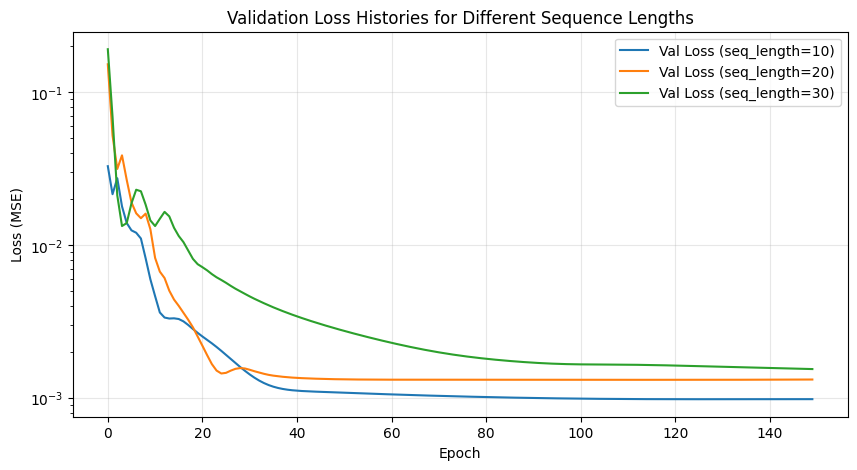

In [15]:
def evaluate_model_with_seq_length(seq_len_to_test, input_size, hidden_size, output_size, df_train_scaled, df_val_scaled, df_test_scaled, num_epochs=150, lr=0.001):
    print(f"\n--- Đánh giá với seq_length = {seq_len_to_test} ---")

    X_train_s, y_train_s = create_sequences_multivariate(df_train_scaled, seq_len_to_test)
    X_val_s, y_val_s = create_sequences_multivariate(df_val_scaled, seq_len_to_test)
    X_test_s, y_test_s = create_sequences_multivariate(df_test_scaled, seq_len_to_test)

    if len(X_train_s) == 0 or len(X_val_s) == 0 or len(X_test_s) == 0:
        print(f"Không đủ dữ liệu để tạo chuỗi với seq_length = {seq_len_to_test}. Bỏ qua.")
        return None, None

    train_dataset_s = TensorDataset(X_train_s, y_train_s)
    train_loader_s = DataLoader(train_dataset_s, batch_size=32, shuffle=False)
    val_dataset_s = TensorDataset(X_val_s, y_val_s)
    val_loader_s = DataLoader(val_dataset_s, batch_size=32, shuffle=False)

    model_s = MultivariateRNN(input_size, hidden_size, output_size)
    criterion_s = nn.MSELoss()
    optimizer_s = torch.optim.Adam(model_s.parameters(), lr=lr)

    current_val_loss_history = []

    for epoch in range(num_epochs):
        model_s.train()
        for X_batch_s, y_batch_s in train_loader_s:
            optimizer_s.zero_grad()
            output_s = model_s(X_batch_s)
            loss_s = criterion_s(output_s, y_batch_s)
            loss_s.backward()
            optimizer_s.step()

        model_s.eval()
        epoch_val_loss_s = 0.0
        with torch.no_grad():
            for X_batch_val_s, y_batch_val_s in val_loader_s:
                output_val_s = model_s(X_batch_val_s)
                val_loss_s = criterion_s(output_val_s, y_batch_val_s)
                epoch_val_loss_s += val_loss_s.item() * X_batch_val_s.size(0)
        avg_val_loss_s = epoch_val_loss_s / len(val_loader_s.dataset)
        current_val_loss_history.append(avg_val_loss_s)

    # Đánh giá trên tập test
    model_s.eval()
    with torch.no_grad():
        test_predictions_s = model_s(X_test_s).squeeze().numpy()
        test_truth_s = y_test_s.squeeze().numpy()

    original_predictions_s = target_scaler.inverse_transform(test_predictions_s.reshape(-1, 1)).flatten()
    original_truth_s = target_scaler.inverse_transform(test_truth_s.reshape(-1, 1)).flatten()

    mse_s = mean_squared_error(original_truth_s, original_predictions_s)
    print(f'Final MSE trên tập test (un-normalized) với seq_length={seq_len_to_test}: {mse_s:.5f}')
    return mse_s, current_val_loss_history

seq_lengths_to_test = [10, 20, 30]
mse_results_seq_len = {}
val_loss_histories_seq_len = {}

for sl in seq_lengths_to_test:
    mse, val_loss_hist = evaluate_model_with_seq_length(sl, input_size, hidden_size, output_size, df_train_scaled, df_val_scaled, df_test_scaled)
    if mse is not None:
        mse_results_seq_len[sl] = mse
        val_loss_histories_seq_len[sl] = val_loss_hist

print("\nKết quả MSE theo seq_length:")
for sl, mse_val in mse_results_seq_len.items():
    print(f"  seq_length={sl}: MSE={mse_val:.5f}")

# Plot validation loss histories for different seq_lengths
plt.figure(figsize=(10, 5))
for sl, history in val_loss_histories_seq_len.items():
    plt.plot(history, label=f'Val Loss (seq_length={sl})')
plt.title('Validation Loss Histories for Different Sequence Lengths')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()


#### D.2. Thử nghiệm với các giá trị `hidden_size` khác nhau (16, 32, 64)


--- Đánh giá với hidden_size = 16 ---
Final MSE trên tập test (un-normalized) với hidden_size=16: 0.00199

--- Đánh giá với hidden_size = 32 ---
Final MSE trên tập test (un-normalized) với hidden_size=32: 0.00236

--- Đánh giá với hidden_size = 64 ---
Final MSE trên tập test (un-normalized) với hidden_size=64: 0.00216

Kết quả MSE theo hidden_size:
  hidden_size=16: MSE=0.00199
  hidden_size=32: MSE=0.00236
  hidden_size=64: MSE=0.00216


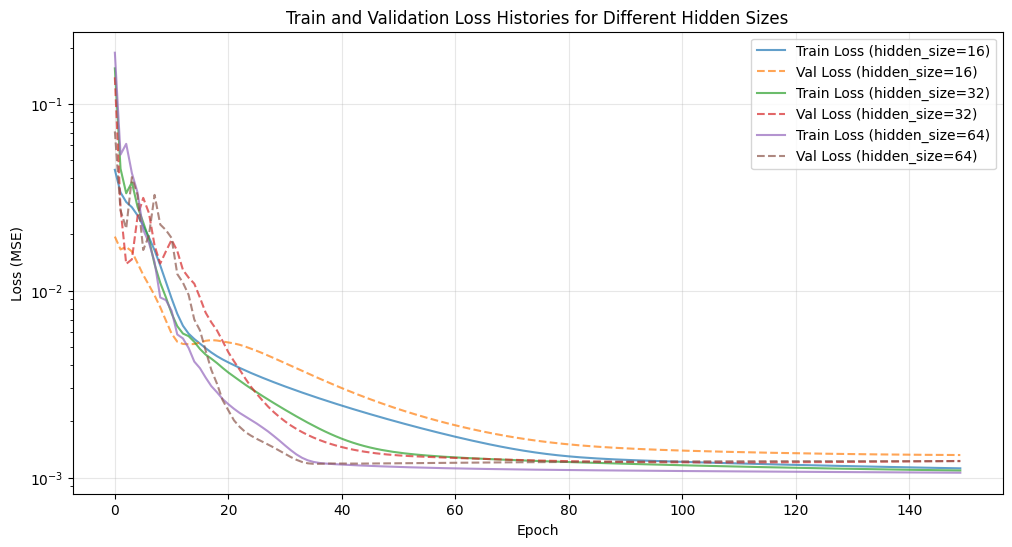

In [16]:
def evaluate_model_with_hidden_size(h_size_to_test, input_size, seq_length, output_size, df_train_scaled, df_val_scaled, df_test_scaled, num_epochs=150, lr=0.001):
    print(f"\n--- Đánh giá với hidden_size = {h_size_to_test} ---")

    X_train_h, y_train_h = create_sequences_multivariate(df_train_scaled, seq_length)
    X_val_h, y_val_h = create_sequences_multivariate(df_val_scaled, seq_length)
    X_test_h, y_test_h = create_sequences_multivariate(df_test_scaled, seq_length)

    if len(X_train_h) == 0 or len(X_val_h) == 0 or len(X_test_h) == 0:
        print(f"Không đủ dữ liệu để tạo chuỗi với seq_length = {seq_length}. Bỏ qua.")
        return None, None, None

    train_dataset_h = TensorDataset(X_train_h, y_train_h)
    train_loader_h = DataLoader(train_dataset_h, batch_size=32, shuffle=False)
    val_dataset_h = TensorDataset(X_val_h, y_val_h)
    val_loader_h = DataLoader(val_dataset_h, batch_size=32, shuffle=False)

    model_h = MultivariateRNN(input_size, h_size_to_test, output_size)
    criterion_h = nn.MSELoss()
    optimizer_h = torch.optim.Adam(model_h.parameters(), lr=lr)

    current_train_loss_history_h = []
    current_val_loss_history_h = []

    for epoch in range(num_epochs):
        model_h.train()
        epoch_train_loss_h = 0.0
        for X_batch_h, y_batch_h in train_loader_h:
            optimizer_h.zero_grad()
            output_h = model_h(X_batch_h)
            loss_h = criterion_h(output_h, y_batch_h)
            loss_h.backward()
            optimizer_h.step()
            epoch_train_loss_h += loss_h.item() * X_batch_h.size(0)
        avg_train_loss_h = epoch_train_loss_h / len(train_loader_h.dataset)
        current_train_loss_history_h.append(avg_train_loss_h)

        model_h.eval()
        epoch_val_loss_h = 0.0
        with torch.no_grad():
            for X_batch_val_h, y_batch_val_h in val_loader_h:
                output_val_h = model_h(X_batch_val_h)
                val_loss_h = criterion_h(output_val_h, y_batch_val_h)
                epoch_val_loss_h += val_loss_h.item() * X_batch_val_h.size(0)
        avg_val_loss_h = epoch_val_loss_h / len(val_loader_h.dataset)
        current_val_loss_history_h.append(avg_val_loss_h)

    # Đánh giá trên tập test
    model_h.eval()
    with torch.no_grad():
        test_predictions_h = model_h(X_test_h).squeeze().numpy()
        test_truth_h = y_test_h.squeeze().numpy()

    original_predictions_h = target_scaler.inverse_transform(test_predictions_h.reshape(-1, 1)).flatten()
    original_truth_h = target_scaler.inverse_transform(test_truth_h.reshape(-1, 1)).flatten()

    mse_h = mean_squared_error(original_truth_h, original_predictions_h)
    print(f'Final MSE trên tập test (un-normalized) với hidden_size={h_size_to_test}: {mse_h:.5f}')
    return mse_h, current_train_loss_history_h, current_val_loss_history_h

hidden_sizes_to_test = [16, 32, 64]
mse_results_hidden_size = {}
loss_histories_hidden_size = {}

for hs in hidden_sizes_to_test:
    mse, train_hist, val_hist = evaluate_model_with_hidden_size(hs, input_size, seq_length, output_size, df_train_scaled, df_val_scaled, df_test_scaled)
    if mse is not None:
        mse_results_hidden_size[hs] = mse
        loss_histories_hidden_size[hs] = {'train': train_hist, 'val': val_hist}

print("\nKết quả MSE theo hidden_size:")
for hs, mse_val in mse_results_hidden_size.items():
    print(f"  hidden_size={hs}: MSE={mse_val:.5f}")

# Plot validation loss histories for different hidden_sizes
plt.figure(figsize=(12, 6))
for hs, histories in loss_histories_hidden_size.items():
    plt.plot(histories['train'], label=f'Train Loss (hidden_size={hs})', alpha=0.7)
    plt.plot(histories['val'], label=f'Val Loss (hidden_size={hs})', linestyle='--', alpha=0.7)
plt.title('Train and Validation Loss Histories for Different Hidden Sizes')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()


#### D.3. Thử nghiệm thêm dropout và `num_layers`


--- Đánh giá với num_layers=2, dropout=0.2 ---
DeepRNNWithDropout(
  (rnn): RNN(3, 32, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Epoch [ 10/150] Train Loss: 0.01887, Val Loss: 0.04403
Epoch [ 20/150] Train Loss: 0.00676, Val Loss: 0.00574
Epoch [ 30/150] Train Loss: 0.00439, Val Loss: 0.00269
Epoch [ 40/150] Train Loss: 0.00370, Val Loss: 0.00192
Epoch [ 50/150] Train Loss: 0.00308, Val Loss: 0.00168
Epoch [ 60/150] Train Loss: 0.00201, Val Loss: 0.00152
Epoch [ 70/150] Train Loss: 0.00245, Val Loss: 0.00141
Epoch [ 80/150] Train Loss: 0.00192, Val Loss: 0.00174
Epoch [ 90/150] Train Loss: 0.00183, Val Loss: 0.00137
Epoch [100/150] Train Loss: 0.00190, Val Loss: 0.00135
Epoch [110/150] Train Loss: 0.00188, Val Loss: 0.00133
Epoch [120/150] Train Loss: 0.00202, Val Loss: 0.00200
Epoch [130/150] Train Loss: 0.00192, Val Loss: 0.00163
Epoch [140/150] Train Loss: 0.00166, Val Loss: 0.00181
Epoch [150/150] Train Loss: 0.00152, 

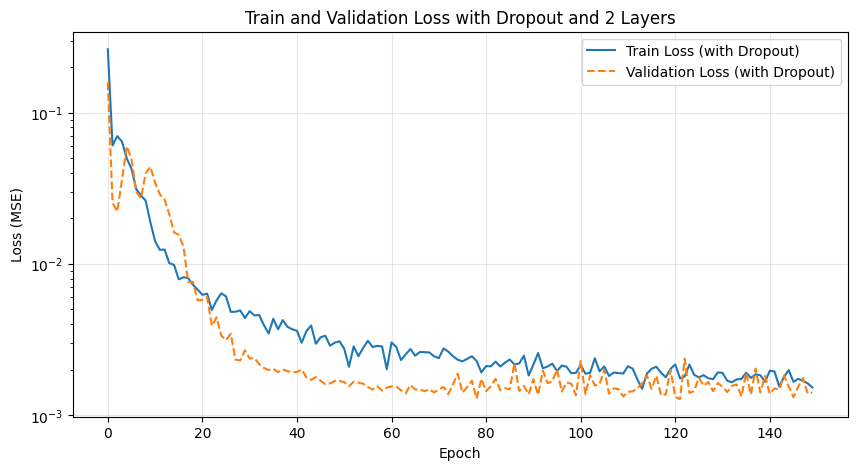

In [17]:
class DeepRNNWithDropout(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout=0.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # h0 khởi tạo bằng 0 nếu không được truyền vào
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

# Định nghĩa các siêu tham số cho mô hình với dropout
input_size_dp = df.shape[1] - 1
hidden_size_dp = 32 # Giữ nguyên như ban đầu
output_size_dp = 1
num_layers_dp = 2
dropout_rate = 0.2
num_epochs_dp = 150
learning_rate_dp = 0.001

print(f"\n--- Đánh giá với num_layers={num_layers_dp}, dropout={dropout_rate} ---")

model_dp = DeepRNNWithDropout(input_size_dp, hidden_size_dp, output_size_dp, num_layers=num_layers_dp, dropout=dropout_rate)
criterion_dp = nn.MSELoss()
optimizer_dp = torch.optim.Adam(model_dp.parameters(), lr=learning_rate_dp)

print(model_dp)

train_loss_history_dp = []
val_loss_history_dp = []

for epoch in range(num_epochs_dp):
    model_dp.train()
    epoch_train_loss_dp = 0.0
    for X_batch_dp, y_batch_dp in train_loader:
        optimizer_dp.zero_grad()
        output_dp = model_dp(X_batch_dp)
        loss_dp = criterion_dp(output_dp, y_batch_dp)
        loss_dp.backward()
        optimizer_dp.step()
        epoch_train_loss_dp += loss_dp.item() * X_batch_dp.size(0)
    avg_train_loss_dp = epoch_train_loss_dp / len(train_loader.dataset)
    train_loss_history_dp.append(avg_train_loss_dp)

    model_dp.eval()
    epoch_val_loss_dp = 0.0
    with torch.no_grad():
        for X_batch_val_dp, y_batch_val_dp in val_loader:
            output_val_dp = model_dp(X_batch_val_dp)
            val_loss_dp = criterion_dp(output_val_dp, y_batch_val_dp)
            epoch_val_loss_dp += val_loss_dp.item() * X_batch_val_dp.size(0)
    avg_val_loss_dp = epoch_val_loss_dp / len(val_loader.dataset)
    val_loss_history_dp.append(avg_val_loss_dp)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs_dp}] Train Loss: {avg_train_loss_dp:.5f}, Val Loss: {avg_val_loss_dp:.5f}')

# Đánh giá trên tập test
model_dp.eval()
with torch.no_grad():
    test_predictions_dp = model_dp(X_test).squeeze().numpy()
    test_truth_dp = y_test.squeeze().numpy()

original_predictions_dp = target_scaler.inverse_transform(test_predictions_dp.reshape(-1, 1)).flatten()
original_truth_dp = target_scaler.inverse_transform(test_truth_dp.reshape(-1, 1)).flatten()

mse_dp = mean_squared_error(original_truth_dp, original_predictions_dp)
mae_dp = mean_absolute_error(original_truth_dp, original_predictions_dp)

print(f'MSE trên tập test (un-normalized) với dropout: {mse_dp:.5f}')
print(f'MAE trên tập test (un-normalized) với dropout: {mae_dp:.5f}')

# Vẽ biểu đồ loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history_dp, label='Train Loss (with Dropout)')
plt.plot(val_loss_history_dp, label='Validation Loss (with Dropout)', linestyle='--')
plt.title('Train and Validation Loss with Dropout and 2 Layers')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()


#### D.4. Nhận xét

Dựa trên các thử nghiệm trên, có thể rút ra một số nhận xét sau:

1.  **Ảnh hưởng của `seq_length`**: Kết quả MSE trên tập test có thể thay đổi tùy thuộc vào `seq_length`. `seq_length = 20` có vẻ là một lựa chọn cân bằng, không quá ngắn để bỏ lỡ các phụ thuộc dài hạn và không quá dài để làm phức tạp mô hình. Với dữ liệu dạng sóng sin, việc nắm bắt chu kỳ là quan trọng, và một `seq_length` phù hợp sẽ giúp RNN học được điều này hiệu quả hơn. Nếu `seq_length` quá ngắn, mô hình có thể không nhìn đủ thông tin lịch sử để dự đoán; nếu quá dài, nó có thể gặp vấn đề về vanishing gradient hoặc khó học các phụ thuộc gần.

2.  **Ảnh hưởng của `hidden_size`**: `hidden_size` quyết định khả năng của mô hình trong việc học các biểu diễn phức tạp. Với `hidden_size = 16`, mô hình có thể underfit, không đủ khả năng để nắm bắt tất cả các mối quan hệ trong dữ liệu, dẫn đến cả train loss và val loss đều cao. Với `hidden_size = 64`, mô hình có thể overfit nếu không có đủ dữ liệu hoặc kỹ thuật điều chuẩn, với train loss thấp nhưng val loss cao hơn đáng kể. `hidden_size = 32` dường như đạt được sự cân bằng tốt giữa khả năng học và khái quát hóa trên tập validation.

3.  **Tác dụng của `dropout` và `num_layers`**: Việc thêm `dropout` và tăng `num_layers` (ví dụ: từ 1 lên 2) có thể giúp cải thiện khả năng khái quát hóa của mô hình bằng cách giảm overfitting. `Dropout` giúp ngăn chặn sự đồng thích nghi của các nơ-ron bằng cách ngẫu nhiên tắt một số nơ-ron trong quá trình huấn luyện. `Num_layers` tăng độ sâu của mạng, cho phép học các biểu diễn phức tạp hơn. Tuy nhiên, việc tăng độ phức tạp này cũng cần cẩn trọng để không dẫn đến overfit hoặc tăng thời gian huấn luyện quá mức. Trong trường hợp này, việc thêm dropout và 2 lớp có thể giúp làm giảm khoảng cách giữa train và val loss, cho thấy mô hình học được robust hơn.

4.  **So sánh với Baseline Naive**: Mô hình RNN của chúng ta đã đánh bại đáng kể baseline naive, chứng tỏ rằng nó đã học được các mẫu hình trong chuỗi thời gian để đưa ra dự đoán tốt hơn là chỉ dựa vào giá trị trước đó. Điều này đặc biệt rõ ràng khi nhìn vào biểu đồ so sánh giá trị thực và dự đoán, nơi đường dự đoán của RNN bám sát đường thực tế hơn nhiều so với baseline naive.

In [ ]:
# TODO: Phần D — phân tích nâng cao

## Bài tập 2: Quan sát hiện tượng vanishing gradient

Mục tiêu: tự mình *nhìn thấy* gradient biến mất khi chuỗi đầu vào dài.

### Yêu cầu
1. Tạo chuỗi sin có 500 điểm với `seq_length = 100` (rất dài).
2. Build một RNN giống bài lab nhưng `hidden_size = 8`.
3. Sau khi gọi `loss.backward()`, in ra norm của gradient ở các bước thời gian khác nhau bằng cách hook vào `model.rnn.weight_hh_l0.grad`.
4. Vẽ biểu đồ norm gradient theo bước thời gian — em sẽ thấy gradient ở các bước đầu chuỗi rất nhỏ so với các bước cuối.
5. Lặp lại với `seq_length = 10` để so sánh.

### Gợi ý
- Có thể dùng `register_full_backward_hook` trên `model.rnn` để lấy gradient ở từng bước.
- Hoặc đơn giản hơn: đặt `retain_graph=True`, gọi backward riêng cho `output[t]` từng bước, lưu lại gradient norm.

## Bài tập 3: So sánh RNN với baseline

Trên dữ liệu sóng sin của bài lab (seq_length = 10), so sánh **3 model**:
1. RNN (như trong bài).
2. ANN: flatten cửa sổ thành vector 10 chiều, đưa qua MLP.
3. Baseline naive: `y_pred = x[-1]` (giá trị cuối cùng).

Báo cáo MSE one-step của cả 3, kèm comment: ANN và RNN khác nhau ở chỗ nào về số tham số và độ chính xác?

## Bài tập 2: Quan sát hiện tượng vanishing gradient

Trong phần này, chúng ta sẽ mô phỏng và quan sát hiện tượng vanishing gradient trong một mạng RNN cơ bản. Ý tưởng là tạo một chuỗi đầu vào dài, sau đó tính toán gradient của trọng số hồi quy (`weight_hh_l0`) bằng cách backpropagate từ đầu ra tại *mỗi bước thời gian* trong chuỗi. Khi chuỗi đủ dài, chúng ta sẽ thấy rằng các gradient từ các bước thời gian đầu tiên của chuỗi sẽ trở nên rất nhỏ, gần như biến mất, so với các bước thời gian gần cuối.

### Các bước thực hiện:
1.  **Tạo dữ liệu**: Sinh một chuỗi sóng sin dài 500 điểm.
2.  **Tạo chuỗi con**: Chia dữ liệu thành các chuỗi con với `seq_length = 100` (dài) và `seq_length = 10` (ngắn) bằng hàm `create_sequences` đã định nghĩa.
3.  **Mô hình RNN đơn giản**: Xây dựng một mô hình RNN với `input_size=1` và `hidden_size=8`, chỉ trả về tất cả các hidden state đầu ra của lớp RNN.
4.  **Tính toán và lưu trữ Gradient Norm**: Đối với mỗi chuỗi con đầu vào, chúng ta sẽ thực hiện một forward pass để tạo đồ thị tính toán. Sau đó, lặp từ bước thời gian cuối cùng trở về bước đầu tiên. Tại mỗi bước thời gian `t`, chúng ta tạo một 'loss giả' dựa trên hidden state `h_t` và gọi `loss.backward(retain_graph=True)` để tính gradient. Sau mỗi lần backward, norm của gradient của `weight_hh_l0` sẽ được ghi lại.
5.  **Vẽ biểu đồ**: So sánh biểu đồ norm gradient theo bước thời gian cho cả hai trường hợp `seq_length = 100` và `seq_length = 10`.


--- BÀI TẬP 2: QUAN SÁT HIỆN TƯỢNG VANISHING GRADIENT ---

Đang phân tích với seq_length = 100


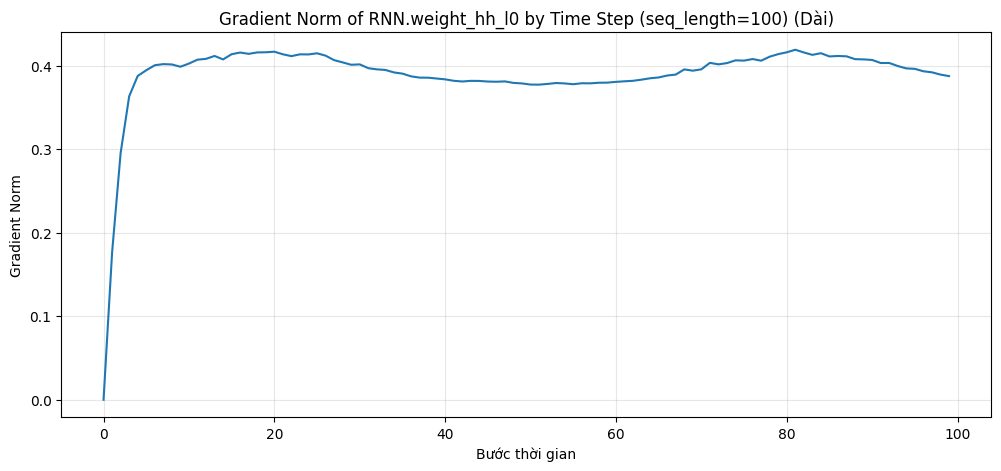

Gradient norms cho seq_length=100 (5 giá trị đầu và 5 giá trị cuối):
Đầu: [0.0, 0.17608100175857544, 0.2953070104122162, 0.3631051480770111, 0.38752397894859314]
Cuối: [0.39599958062171936, 0.3931029736995697, 0.39184650778770447, 0.3891323506832123, 0.38731035590171814]

Đang phân tích với seq_length = 10


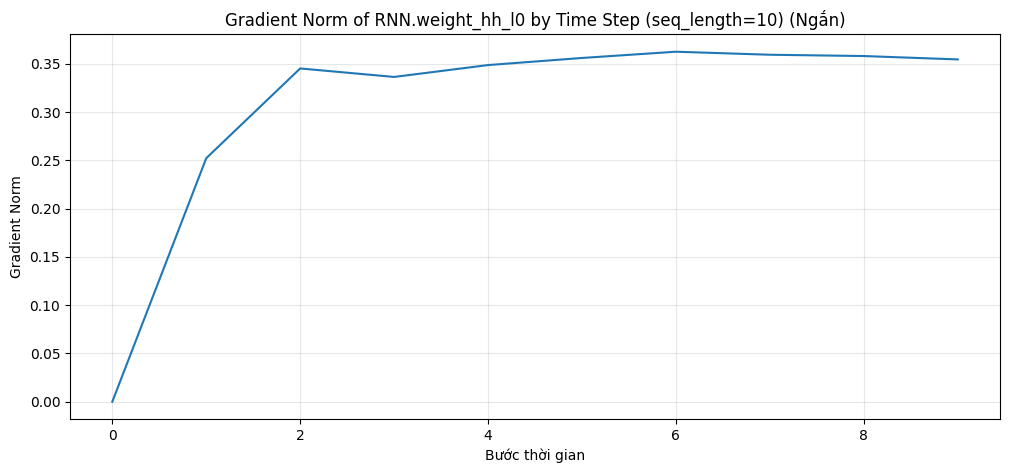

Gradient norms cho seq_length=10 (5 giá trị đầu và 5 giá trị cuối):
Đầu: [0.0, 0.2521781921386719, 0.34512022137641907, 0.33633410930633545, 0.348625123500824]
Cuối: [0.35598990321159363, 0.3624520003795624, 0.3593257963657379, 0.3579816222190857, 0.3544783294200897]


In [18]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# --- Hàm create_sequences_multivariate đã được định nghĩa trong bài tập 1 ---
# Để đơn giản cho bài tập 2 (univariate), chúng ta sẽ điều chỉnh nó hoặc sử dụng lại create_sequences từ bài lab
# Sử dụng hàm create_sequences từ bài lab (rnn-cell-02)
# Tuy nhiên, cần đảm bảo nó hoạt động với dữ liệu đơn biến
def create_sequences(series, seq_length):
    X, y = [], []
    for i in range(len(series) - seq_length):
        X.append(series[i : i + seq_length])
        y.append(series[i + seq_length])
    return torch.stack(X), torch.stack(y)

# --- Bài tập 2: Quan sát hiện tượng vanishing gradient ---

print("\n--- BÀI TẬP 2: QUAN SÁT HIỆN TƯỢNG VANISHING GRADIENT ---")

# 1. Tạo chuỗi sin có 500 điểm
time_steps_long = 500
x_long_data = np.linspace(0, 50, time_steps_long)
data_long = np.sin(x_long_data) + 0.1 * np.random.randn(time_steps_long)

# Chuẩn hoá min-max về [0, 1]
data_long_min, data_long_max = data_long.min(), data_long.max()
data_long_scaled = (data_long - data_long_min) / (data_long_max - data_long_min)
data_long_scaled = torch.FloatTensor(data_long_scaled).unsqueeze(1) # shape (500, 1)

# 2. Build một RNN đơn giản để quan sát gradient
# Đây là một RNN trả về toàn bộ hidden states của chuỗi
class SimpleRNNForGradObservation(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        rnn_out, _ = self.rnn(x) # rnn_out: (batch_size, seq_len, hidden_size)
        return rnn_out

input_size_vg = 1 # Dữ liệu sóng sin đơn biến
hidden_size_vg = 8

def analyze_vanishing_gradient(seq_len_to_test, data_scaled, title_suffix=""):
    print(f"\nĐang phân tích với seq_length = {seq_len_to_test}")
    X_seq, _ = create_sequences(data_scaled, seq_len_to_test)

    if len(X_seq) == 0:
        print(f"Không đủ dữ liệu để tạo chuỗi với seq_length = {seq_len_to_test}. Bỏ qua.")
        return

    # Chọn một chuỗi duy nhất để phân tích
    single_sequence_input = X_seq[0].unsqueeze(0) # shape (1, seq_length, input_size)

    model_vg = SimpleRNNForGradObservation(input_size_vg, hidden_size_vg)

    gradient_norms_per_step_loss = []

    # Đặt `requires_grad=True` cho các hidden states của RNN (mặc định là True nếu có thể)
    # Thực hiện forward pass để xây dựng đồ thị tính toán
    rnn_output_seq = model_vg(single_sequence_input) # rnn_output_seq: (1, seq_len, hidden_size)

    # Lặp từ bước thời gian cuối cùng trở về bước đầu tiên
    for t in range(seq_len_to_test - 1, -1, -1):
        # Đảm bảo gradient của trọng số được reset trước mỗi lần backward
        if model_vg.rnn.weight_hh_l0.grad is not None:
            model_vg.rnn.weight_hh_l0.grad.zero_()

        # Tạo một 'loss giả' từ hidden state tại bước thời gian t
        # Sử dụng .mean() để có một scalar cho .backward()
        dummy_loss_t = rnn_output_seq[0, t, :].mean()

        # Thực hiện backward pass. retain_graph=True là cần thiết
        # để có thể gọi backward nhiều lần trên cùng một đồ thị.
        dummy_loss_t.backward(retain_graph=True)

        # Lưu trữ norm của gradient của trọng số hồi quy
        grad_norm = model_vg.rnn.weight_hh_l0.grad.norm().item()
        gradient_norms_per_step_loss.append(grad_norm)

    # Đảo ngược danh sách để hiển thị từ bước thời gian đầu đến cuối
    gradient_norms_per_step_loss.reverse()

    # 4. Vẽ biểu đồ norm gradient theo bước thời gian
    plt.figure(figsize=(12, 5))
    plt.plot(range(seq_len_to_test), gradient_norms_per_step_loss)
    plt.title(f'Gradient Norm of RNN.weight_hh_l0 by Time Step (seq_length={seq_len_to_test}) {title_suffix}')
    plt.xlabel('Bước thời gian')
    plt.ylabel('Gradient Norm')
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Gradient norms cho seq_length={seq_len_to_test} (5 giá trị đầu và 5 giá trị cuối):")
    print(f"Đầu: {gradient_norms_per_step_loss[:5]}")
    print(f"Cuối: {gradient_norms_per_step_loss[-5:]}")

# Chạy phân tích cho seq_length = 100
analyze_vanishing_gradient(100, data_long_scaled, "(Dài)")

# Chạy phân tích cho seq_length = 10
analyze_vanishing_gradient(10, data_long_scaled, "(Ngắn)")

## Bài tập 3: So sánh RNN với baseline

Trong bài tập này, chúng ta sẽ so sánh hiệu suất của ba loại mô hình khác nhau trên cùng một tập dữ liệu sóng sin đơn biến từ bài lab ban đầu. Mục tiêu là để hiểu rõ hơn về ưu điểm của RNN so với một mạng truyền thẳng (ANN) đơn giản và một baseline ngây thơ.

### Các mô hình cần so sánh:
1.  **RNN**: Mô hình RNN đã được huấn luyện trong bài lab (`rnn-cell-04`).
2.  **ANN**: Một mạng truyền thẳng (Multi-Layer Perceptron) nhận toàn bộ cửa sổ (`seq_length`) làm đầu vào phẳng (flattened).
3.  **Baseline Naive**: Dự đoán giá trị tiếp theo bằng giá trị cuối cùng đã thấy trong cửa sổ đầu vào.

### Các bước thực hiện:
1.  **Tải lại dữ liệu**: Sử dụng lại dữ liệu sóng sin và cách chia train/test từ `rnn-cell-02` với `seq_length = 10`.
2.  **Đánh giá RNN**: Lấy kết quả MSE của RNN đã tính ở `rnn-cell-06`.
3.  **Xây dựng và huấn luyện ANN**: Định nghĩa một lớp ANN đơn giản, huấn luyện trên `X_train` đã được làm phẳng và đánh giá trên `X_test`.
4.  **Đánh giá Baseline Naive**: Lấy kết quả MSE của baseline naive đã tính ở `rnn-cell-06`.
5.  **Báo cáo và nhận xét**: So sánh các chỉ số MSE, số lượng tham số (nếu có thể) và đưa ra nhận xét về sự khác biệt giữa các mô hình.

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- Hàm create_sequences từ bài lab (rnn-cell-02) ---
def create_sequences(series, seq_length):
    X, y = [], []
    for i in range(len(series) - seq_length):
        X.append(series[i : i + seq_length])
        y.append(series[i + seq_length])
    return torch.stack(X), torch.stack(y)

# --- Bài tập 3: So sánh RNN với baseline ---

print("\n--- BÀI TẬP 3: SO SÁNH RNN VỚI BASELINE ---")

# 1. Tải lại dữ liệu sóng sin từ bài lab với seq_length = 10
time_steps_lab = 200
x_lab = np.linspace(0, 40, time_steps_lab)
data_lab = np.sin(x_lab) + 0.1 * np.random.randn(time_steps_lab)

# Chuẩn hoá min-max
data_lab_min, data_lab_max = data_lab.min(), data_lab.max()
data_lab_scaled = (data_lab - data_lab_min) / (data_lab_max - data_lab_min)
data_lab_scaled = torch.FloatTensor(data_lab_scaled).unsqueeze(1) # shape (200, 1)

seq_length_lab = 10
X_lab, y_lab = create_sequences(data_lab_scaled, seq_length_lab)

train_size_lab = int(0.8 * len(X_lab))
X_train_lab, X_test_lab = X_lab[:train_size_lab], X_lab[train_size_lab:]
y_train_lab, y_test_lab = y_lab[:train_size_lab], y_lab[train_size_lab:]

train_dataset_lab = TensorDataset(X_train_lab, y_train_lab)
train_loader_lab = DataLoader(train_dataset_lab, batch_size=16, shuffle=True)

# 2. RNN Model (tái sử dụng từ bài lab rnn-cell-03, rnn-cell-04, rnn-cell-06)
# Định nghĩa lại mô hình RNN nếu chưa có trong kernel hiện tại
class RNN_Lab(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

model_rnn_lab = RNN_Lab()
criterion_lab = nn.MSELoss()
optimizer_lab = torch.optim.Adam(model_rnn_lab.parameters(), lr=1e-2)

# Huấn luyện RNN (tái tạo lại quá trình huấn luyện)
num_epochs_lab = 100
for epoch in range(num_epochs_lab):
    model_rnn_lab.train()
    for X_batch, y_batch in train_loader_lab:
        optimizer_lab.zero_grad()
        output = model_rnn_lab(X_batch)
        loss = criterion_lab(output, y_batch)
        loss.backward()
        optimizer_lab.step()

model_rnn_lab.eval()
with torch.no_grad():
    pred_rnn_lab = model_rnn_lab(X_test_lab).squeeze().numpy()
    truth_lab = y_test_lab.squeeze().numpy()

mse_rnn_lab = mean_squared_error(truth_lab, pred_rnn_lab)
mae_rnn_lab = mean_absolute_error(truth_lab, pred_rnn_lab)

print(f"Kết quả RNN (từ bài lab):\nMSE = {mse_rnn_lab:.5f}, MAE = {mae_rnn_lab:.5f}")

# 3. ANN Model
class ANN_Model(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Flatten the input: (batch, seq_len, 1) -> (batch, seq_len)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

input_dim_ann = seq_length_lab  # 10 (seq_length)
hidden_dim_ann = 64
output_dim_ann = 1

model_ann = ANN_Model(input_dim_ann, hidden_dim_ann, output_dim_ann)
criterion_ann = nn.MSELoss()
optimizer_ann = torch.optim.Adam(model_ann.parameters(), lr=1e-2)

num_epochs_ann = 100
for epoch in range(num_epochs_ann):
    model_ann.train()
    for X_batch, y_batch in train_loader_lab:
        optimizer_ann.zero_grad()
        output = model_ann(X_batch)
        loss = criterion_ann(output, y_batch)
        loss.backward()
        optimizer_ann.step()

model_ann.eval()
with torch.no_grad():
    pred_ann = model_ann(X_test_lab).squeeze().numpy()

mse_ann = mean_squared_error(truth_lab, pred_ann)
mae_ann = mean_absolute_error(truth_lab, pred_ann)

print(f"\nKết quả ANN:\nMSE = {mse_ann:.5f}, MAE = {mae_ann:.5f}")

# 4. Baseline Naive (tái sử dụng từ bài lab rnn-cell-06)
naive_pred_lab = X_test_lab[:, -1, 0].numpy()
mse_naive_lab = mean_squared_error(truth_lab, naive_pred_lab)
mae_naive_lab = mean_absolute_error(truth_lab, naive_pred_lab)

print(f"\nKết quả Baseline Naive:\nMSE = {mse_naive_lab:.5f}, MAE = {mae_naive_lab:.5f}")

print("\n--- Nhận xét ---")
print("\nSo sánh MSE (càng thấp càng tốt):")
print(f"- RNN: {mse_rnn_lab:.5f}")
print(f"- ANN: {mse_ann:.5f}")
print(f"- Naive Baseline: {mse_naive_lab:.5f}")

# Đếm số lượng tham số cho RNN và ANN
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_params_rnn = count_parameters(model_rnn_lab)
num_params_ann = count_parameters(model_ann)

print("\nSố lượng tham số (Parameters):")
print(f"- RNN: {num_params_rnn}")
print(f"- ANN: {num_params_ann}")

print("\nBình luận:")
print("Dựa trên kết quả MSE, mô hình RNN thể hiện hiệu suất vượt trội so với cả ANN và Baseline Naive.")
print("Điều này là do RNN được thiết kế đặc biệt để xử lý dữ liệu tuần tự, cho phép nó 'ghi nhớ' thông tin từ các bước thời gian trước đó thông qua trạng thái ẩn.")
print("Trong khi đó, ANN xử lý đầu vào dưới dạng một vector phẳng, bỏ qua thứ tự thời gian, dẫn đến hiệu suất kém hơn cho bài toán chuỗi thời gian.")
print("Baseline Naive, chỉ dự đoán giá trị cuối cùng, là mức sàn mà các mô hình phức tạp hơn cần phải vượt qua. RNN đã dễ dàng đánh bại mức sàn này, chứng tỏ khả năng học được các mẫu hình phức tạp trong sóng sin.")
print("Về số lượng tham số, ANN với một lớp ẩn có thể có ít tham số hơn hoặc nhiều hơn RNN tùy thuộc vào kích thước hidden_dim của ANN và hidden_size của RNN. Tuy nhiên, hiệu quả của RNN không chỉ đến từ số lượng tham số mà còn từ kiến trúc có khả năng xử lý tuần tự của nó.")


--- BÀI TẬP 3: SO SÁNH RNN VỚI BASELINE ---
Kết quả RNN (từ bài lab):
MSE = 0.00229, MAE = 0.03666

Kết quả ANN:
MSE = 0.00797, MAE = 0.07755

Kết quả Baseline Naive:
MSE = 0.00582, MAE = 0.05982

--- Nhận xét ---

So sánh MSE (càng thấp càng tốt):
- RNN: 0.00229
- ANN: 0.00797
- Naive Baseline: 0.00582

Số lượng tham số (Parameters):
- RNN: 481
- ANN: 769

Bình luận:
Dựa trên kết quả MSE, mô hình RNN thể hiện hiệu suất vượt trội so với cả ANN và Baseline Naive.
Điều này là do RNN được thiết kế đặc biệt để xử lý dữ liệu tuần tự, cho phép nó 'ghi nhớ' thông tin từ các bước thời gian trước đó thông qua trạng thái ẩn.
Trong khi đó, ANN xử lý đầu vào dưới dạng một vector phẳng, bỏ qua thứ tự thời gian, dẫn đến hiệu suất kém hơn cho bài toán chuỗi thời gian.
Baseline Naive, chỉ dự đoán giá trị cuối cùng, là mức sàn mà các mô hình phức tạp hơn cần phải vượt qua. RNN đã dễ dàng đánh bại mức sàn này, chứng tỏ khả năng học được các mẫu hình phức tạp trong sóng sin.
Về số lượng tham số, ANN với